# Tilbury tuning-law fits

Load a random Blender-VR imaging session, run `TilburyFitConfig.process`, and inspect the per-neuron fits.

Each neuron is fit (train split) to a sum of up to two asymmetric generalized-Gaussian peaks; 1-vs-2 peaks chosen on validation, R² reported on test.

In [2]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

from collections import defaultdict
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from syd import Viewer

from vrAnalysis.database import get_database
from vrAnalysis.helpers import edge2center
from vrAnalysis.helpers.plotting import beeswarm
from vrAnalysis.processors import SpkmapProcessor
from dimensionality_manuscript.configs import get_data_config
from dimensionality_manuscript.registry import PopulationRegistry
from dimensionality_manuscript import ResultsStore, ResultsAggregator
from dimensionality_manuscript.configs.tilbury_fit import TilburyFitConfig, _eval_tilbury, _eval_gaussian
from dimensionality_manuscript import average_by_mouse

plt.rcParams["font.size"] = 14

sessiondb = get_database("vrSessions")
registry = PopulationRegistry(registry_params=get_data_config("even").to_registry_params())

In [3]:
sessions = sessiondb.iter_sessions(imaging=True, experimentType="Blender VR")
store = ResultsStore()
cfg = TilburyFitConfig() #schema_version="v2")
results = ResultsAggregator(cfg, store, sessions)

In [3]:
def xvals(x):
    return np.arange(x.shape[1]) + 1

class TilburyFitViewer(Viewer):
    def __init__(self, results: ResultsAggregator):
        self = cfg.build_syd(self, results)
        self.update_selection("view_by", value="session")
        self.add_integer("num_bins", value=80, min=5, max=100)

        preferred_state = {
            # "smooth_width": 5.0,
            # "activity_parameters_name": "default",
        }
        for key, value in preferred_state.items():
            self.update_selection(key, value=value)

    def plot(self, state: dict):
        result, axes_names = self.get_result(state, load_ragged=True)
        idx_valid = ~np.all(np.isnan(result["r2_test"]), axis=1)
        idx_peak = cfg.param_names.index("p")
        peak = result["params"][..., idx_peak][idx_valid]
        r2_test = result["r2_test"][idx_valid]
        r2_test_control = result["r2_test_control"][idx_valid]
        idx_keep = result["idx_keep"][idx_valid]
        mouse_names = results.mouse_names[idx_valid]

        avg_r2 = np.full((r2_test.shape[0], 2), np.nan)
        for idx, (r2, r2c) in enumerate(zip(r2_test, r2_test_control)):
            avg_r2[idx, 0] = np.nanmedian(r2)
            avg_r2[idx, 1] = np.nanmedian(r2c)

        improvement = r2_test - r2_test_control

        fraction_better = np.full(r2_test.shape[0], np.nan)
        for idx, imp in enumerate(improvement):
            ikeep = idx_keep[idx]
            num_keep = int(np.nansum(ikeep))
            fraction_better[idx] = np.nansum(imp > 0) / num_keep

        # Do KDE smoothing for each session's neurons
        edges_peak = np.linspace(0.0, 10.0, state["num_bins"] + 1)
        centers_peak = edge2center(edges_peak)
        density_peak = np.full((peak.shape[0], len(centers_peak)), np.nan)
        edges_improvement = np.linspace(-5.0, 5.0, state["num_bins"] + 1)
        centers_improvement = edge2center(edges_improvement)
        density_improvement = np.full((improvement.shape[0], len(centers_improvement)), np.nan)
        for i, (row_peak, row_improvement) in enumerate(zip(peak, improvement)):
            row_peak = row_peak[np.isfinite(row_peak)]
            if len(row_peak) < 2: 
                continue
            kde = gaussian_kde(row_peak)
            density_peak[i] = kde(centers_peak)

            row_improvement = row_improvement[np.isfinite(row_improvement)]
            if len(row_improvement) < 2: 
                continue
            kde = gaussian_kde(row_improvement)
            density_improvement[i] = kde(centers_improvement)

        # Density by mouse
        mouse_density_peak = average_by_mouse(density_peak, mouse_names)
        mouse_density_improvement = average_by_mouse(density_improvement, mouse_names)
        mouse_fraction_better = average_by_mouse(fraction_better, mouse_names)
        mouse_avg_r2 = average_by_mouse(avg_r2, mouse_names)
        
        # Plot density
        fig, ax = plt.subplots(1, 4, figsize=(12, 4), width_ratios=[1, 1, 0.3, 0.5], layout="constrained")
        ax[0].plot(centers_peak, mouse_density_peak.T)
        ax[0].axvline(x=2.0, color="k", linestyle=":", linewidth=0.5)
        ax[0].set_xticks([0, 2, 4, 6, 8, 10])
        ax[0].set_xlabel("Peak Exponent")
        ax[0].set_ylabel("Density")

        ax[1].plot(centers_improvement, mouse_density_improvement.T)
        ax[1].set_xlabel("Generalized R2 - Gaussian R2")
        ax[1].set_ylabel("Density")

        beewidth = 0.25
        ax[2].plot(beewidth * beeswarm(mouse_fraction_better), mouse_fraction_better, linestyle="none", color="black", marker="o", markersize=4, alpha=0.8)
        ax[2].set_ylabel("Fraction Cells\nGeneralized > Gaussian")
        ax[2].set_xticks([])
        ax[2].set_xlim(-0.5, 0.5)
        ax[2].set_ylim(0, 1)

        ax[3].plot([0, 1], mouse_avg_r2.T, color="black", marker="o", markersize=4)
        ax[3].set_ylabel("Test R Squared")
        ax[3].set_xticks([0, 1])
        ax[3].set_xlim(-0.5, 1.5)
        ax[3].set_xticklabels(["Generalized", "Gaussian"], rotation=45, ha="right")

        return fig

viewer = TilburyFitViewer(results)
viewer.show()

## Pick a random session

In [18]:
sessions = sessiondb.iter_sessions(imaging=True, experimentType="Blender VR")
print(f"{len(sessions)} Blender-VR imaging sessions")

rng = np.random.default_rng()
# session = sessions[rng.integers(len(sessions))]
session = sessions[41]
print(session)
print("Environments:", session.environments)
for env in session.environments:
    print("  env", env, "num_trials:", int(np.sum(session.trial_environment == env)))

140 Blender-VR imaging sessions
B2Session(mouse_name='ATL022', date='2023-04-21', session_id='701', spks_type='significant')
Environments: [1 3]
  env 1 num_trials: 49
  env 3 num_trials: 52


## Run the fit

In [19]:
cfg = TilburyFitConfig(
    spks_type="sigrebase",
    num_bins=100,
    reliability_fraction_active_thresholds=(0.5, 0.1),
)
print(cfg.summary())

result = cfg.process(session, registry, verbose=True, device="cpu", gd_learning_rate=0.1, gd_num_steps=8000)
print(np.nanmedian(result["r2_test"]), np.nanmedian(result["r2_test_control"]))

for k, v in result.items():
    shape = getattr(v, "shape", v)
    print(f"{k:16s}: {shape}")

tilbury_fit_spks=sigrebase_ap=raw_bins=100_rel=0.5_frac=0.1_v5


descent fit control: 100%|██████████| 8000/8000 [00:18<00:00, 430.02it/s, loss=1.551e+05]


0.5268812614551985 0.5199962000934057
params          : (1319, 6)
r2_train        : (1319,)
r2_val          : (1319,)
r2_test         : (1319,)
pearson_train   : (1319,)
pearson_val     : (1319,)
pearson_test    : (1319,)
params_control  : (1319, 4)
r2_train_control: (1319,)
r2_val_control  : (1319,)
r2_test_control : (1319,)
pearson_train_control: (1319,)
pearson_val_control: (1319,)
pearson_test_control: (1319,)
idx_keep        : (8562,)
eig_tilbury     : (99,)
eig_control     : (99,)
eig_better      : (99,)
eig_raw_train   : (99,)
eig_raw_test    : (99,)
dist_centers    : (99,)
best_env        : ()
param_names     : ['b', 'A', 'phi', 'sigma_left', 'sigma_right', 'p']
param_names_control: ['b', 'A', 'phi', 'sigma']


In [10]:
population, frame_behavior = registry.get_population(session, cfg.spks_type)
spkmap = SpkmapProcessor(session)
reliability = (
    spkmap.get_reliability(use_session_filters=False)
    .filter_rois(population.idx_neurons)
    .filter_rois(result["idx_keep"])
    .filter_by_environment([result["best_env"]])
)
best_env_reliability = reliability.values[0]

## Summary stats

In [11]:
# Least squares stats
r2_test = result["r2_test"]
r2_test_control = result["r2_test_control"]

print(f"Neurons kept       : {result['idx_keep'].sum()} / {result['idx_keep'].shape[0]}")
print(f"Best environment   : {result['best_env']}")
print(f"Position bins used : {result['dist_centers'].shape[0]}")
print(f"median test R2     : {np.nanmedian(r2_test):.3f}")
print(f"frac test R2 > 0.5 : {np.nanmean(r2_test > 0.5):.3f}")
print(f"frac test R2 > 0.0 : {np.nanmean(r2_test > 0.0):.3f}")
print(f"CTL: median test R2     : {np.nanmedian(r2_test_control):.3f}")
print(f"CTL: frac test R2 > 0.5 : {np.nanmean(r2_test_control > 0.5):.3f}")
print(f"CTL: frac test R2 > 0.0 : {np.nanmean(r2_test_control > 0.0):.3f}")

Neurons kept       : 8 / 2826
Best environment   : 1
Position bins used : 98
median test R2     : -0.629
frac test R2 > 0.5 : 0.250
frac test R2 > 0.0 : 0.375
CTL: median test R2     : -0.617
CTL: frac test R2 > 0.5 : 0.125
CTL: frac test R2 > 0.0 : 0.375


0.5


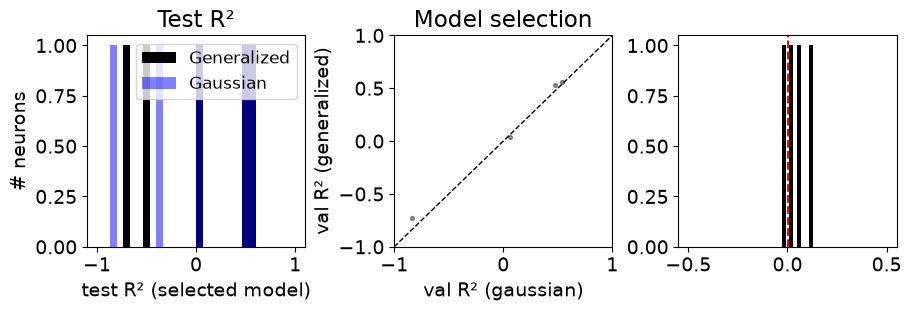

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(9, 3), layout="constrained")

axs[0].hist(r2_test[np.isfinite(r2_test)], bins=30, range=(-1.0, 1), label="Generalized", color="black")
axs[0].hist(r2_test_control[np.isfinite(r2_test_control)], bins=30, range=(-1.0, 1), label="Gaussian", color=("blue", 0.5))
axs[0].set(xlabel="test R² (selected model)", ylabel="# neurons", title="Test R²")
axs[0].legend(loc="upper right", fontsize=12)

axs[1].scatter(r2_test_control, r2_test, s=8, alpha=0.4, color="black")
axs[1].plot([-1.0, 1], [-1.0, 1], "k--", lw=1)
axs[1].set(xlabel="val R² (gaussian)", ylabel="val R² (generalized)", title="Model selection", xlim=(-1.0, 1), ylim=(-1.0, 1))

idx_valid = np.logical_and(np.isfinite(r2_test), np.isfinite(r2_test_control))
r2_improvement = r2_test[idx_valid] - r2_test_control[idx_valid]
print(np.sum(r2_improvement > 0) / len(r2_improvement))
axs[2].hist(r2_improvement, bins=51, range=(-0.5, 0.5), color="black")
axs[2].axvline(np.median(r2_improvement), color="r", linestyle="--", linewidth=1.5)
plt.show()

## Example fits overlaid on the test placefield

Re-derive the test-split averaged placefield (via the config's own helpers) to overlay data vs fitted model for the best-fit neurons.

In [13]:
# Rebuild the test-split curve on the same bins the fit used.
theta = result["dist_centers"]
best_env = result["best_env"]
dist_edges = np.linspace(0, session.env_length[0], cfg.num_bins + 1)
good = np.isin(edge2center(dist_edges), theta)

spks, fb = cfg._get_split_data(session, registry)
for s in spks:
    spks[s] = spks[s][:, result["idx_keep"]]

test_curve_full, _ = cfg._avg_placefield(spks["test"], fb["test"], dist_edges, best_env, session)
test_curve = test_curve_full[:, good]
print("test_curve shape:", test_curve.shape)

test_curve shape: (8, 98)


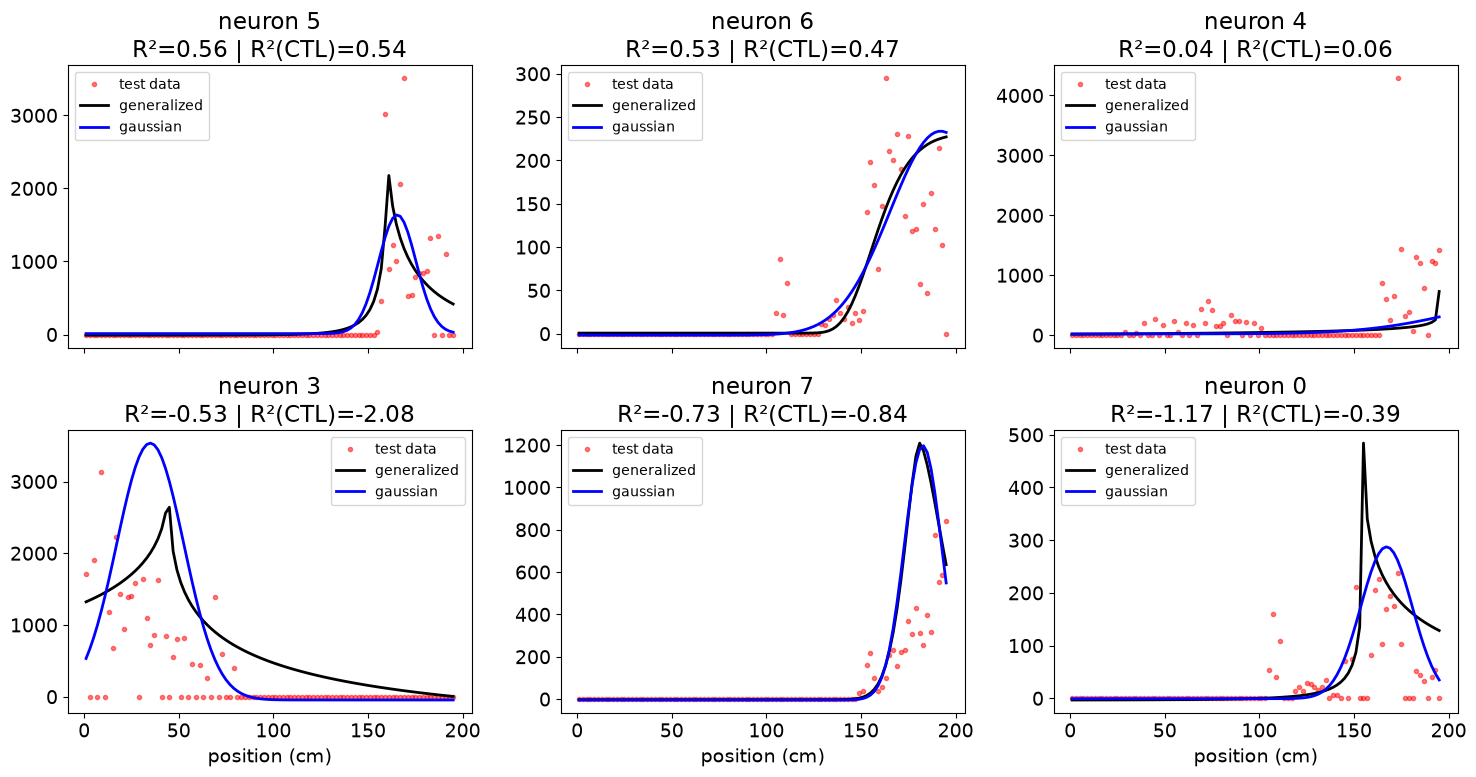

In [14]:
# Top 6 neurons by test R2.
order = np.argsort(np.nan_to_num(r2_test, nan=-np.inf))[::-1][:6]

fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for ax, n in zip(axs.flat, order):
    params = result["params"][n]
    fitted = _eval_tilbury(theta, params)
    params_control = result["params_control"][n]
    fitted_control = _eval_gaussian(theta, params_control, )
    ax.plot(theta, test_curve[n], "ro", ms=3, alpha=0.5, label="test data")
    ax.plot(theta, fitted, "k-", lw=2, label=f"generalized")
    ax.plot(theta, fitted_control, "b-", lw=2, label=f"gaussian")
    ax.set_title(f"neuron {n}\nR²={r2_test[n]:.2f} | R²(CTL)={r2_test_control[n]:.2f}")
    ax.legend(fontsize=10)
for ax in axs[-1]:
    ax.set_xlabel("position (cm)")
fig.tight_layout()
plt.show()

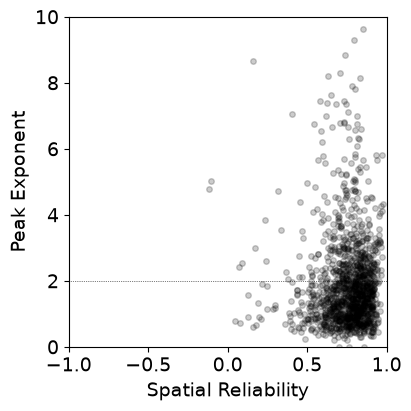

In [58]:
alpha = 0.2
line_params = lambda color, alpha, label: {
    "color": (color, alpha), 
    "linestyle": "none",
    "marker": ".",
    "markersize": 8,
    "label": label,
}
plt.close('all')
fig, ax = plt.subplots(1, 1, figsize=(4, 4), layout="constrained", sharex="col", sharey=True)
ax.plot(best_env_reliability, result["params"][:, 5], **line_params("black", alpha, None))
ax.set_xlabel("Spatial Reliability")
ax.set_ylabel("Peak Exponent")

ax.set_xlim(-1, 1)
ax.set_ylim(0, 10)
ax.axhline(y=2.0, color="k", linestyle=":", linewidth=0.5)
plt.show()

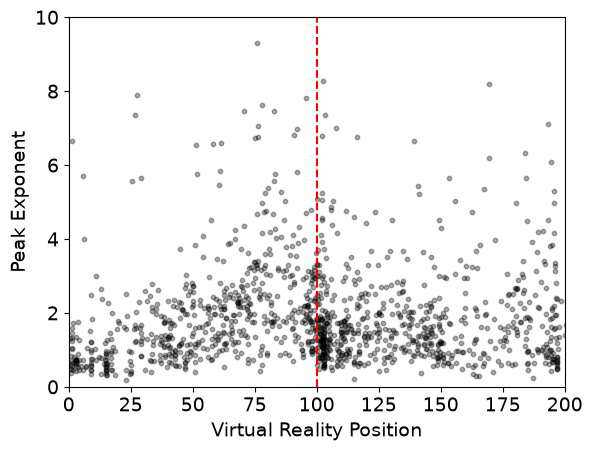

In [59]:
# Compare peakiness probability to location (relative to placefield!)
environmentIndex = session.loadone("trials.environmentIndex")
rewardPosition = session.loadone("trials.rewardPosition")
rewardTolerance = session.loadone("trials.rewardZoneHalfwidth")
env_to_reward = {e: r - t for e, r, t in zip(environmentIndex, rewardPosition, rewardTolerance)}
unique_env_to_reward = dict(set(env_to_reward.items()))

idx_peak1 = result["param_names"].index("phi")
idx_p1 = result["param_names"].index("p")
plt.close('all')
plt.scatter(result["params"][:, idx_peak1], result["params"][:, idx_p1], s=10, c="k", alpha=0.33)
plt.axvline(x=unique_env_to_reward[result["best_env"]], color="red", linestyle="--")
plt.xlabel("Virtual Reality Position")
plt.ylabel("Peak Exponent")
plt.xlim(0, session.env_length[0])
plt.ylim(0, 10)
plt.show()